<a href="https://colab.research.google.com/github/tentorifrancescaDev/phishing-detection-robustness/blob/main/Progetto_AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Progetto Architettura Dati

## Importazione Librerie e Dataset Phishing

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, precision_recall_fscore_support,roc_auc_score
from sklearn.base import clone
from keras.models import Sequential
from keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


from scipy.stats import ttest_rel, wilcoxon
from scipy.stats import t as t_dist

### Importazione dataset di Phihsing

In [ ]:
# fetch dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

# data (as pandas dataframes)
X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

df = pd.concat([X, y], axis=1)

print(df.head())
# rinomino la variabili categoriche in 'category'
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

                                  URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26           0  org               100.0              1.000000   

   TLDLegitimateProb  URLCharProb  ...  Pay  Crypt

## EDA

### EDA Univariata

Numero di righe (istanze): 235795
Numero di colonne (feature): 55

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   URL                         235795 non-null  category
 1   URLLength                   235795 non-null  int64   
 2   Domain                      235795 non-null  category
 3   DomainLength                235795 non-null  int64   
 4   IsDomainIP                  235795 non-null  int64   
 5   TLD                         235795 non-null  category
 6   URLSimilarityIndex          235795 non-null  float64 
 7   CharContinuationRate        235795 non-null  float64 
 8   TLDLegitimateProb           235795 non-null  float64 
 9   URLCharProb                 235795 non-null  float64 
 10  TLDLength                   235795 non-null  int64   
 11  NoOfSubDomain               235795 non-null  int64

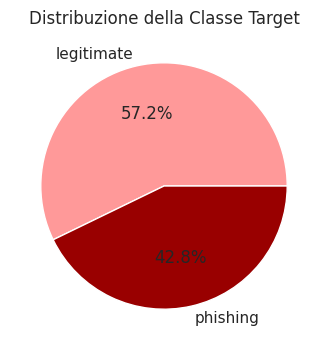

In [ ]:
print(f"Numero di righe (istanze): {df.shape[0]}")
print(f"Numero di colonne (feature): {df.shape[1]}\n")

# Mostra i tipi di ogni colonna (int64, float64, category)
print(df.info())
print("\n")

# Conta se ci sono celle vuote nel dataset
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Nessun valore mancante rilevato!")
print("\n")

# Controlliamo il bilanciamento esatto della colonna target (solitamente si chiama 'label' o 'Label')
# 1 = Legittimo, 0 = Phishing
target_col = y.columns[0]
print(df[target_col].value_counts())
print("\nProporzioni percentuali:")
print(df[target_col].value_counts(normalize=True) * 100)
print("\n")

# Genera media, deviazione standard, minimo, massimo e percentili
print(df.describe().T) # Usiamo .T (trasposta) per leggere meglio le 54 colonne in verticale

sns.set_theme(style="whitegrid")

class_counts = df['label'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(class_counts.values, labels = ['legitimate', 'phishing'], autopct='%1.1f%%', colors=['#ff9999', '#990000'])

plt.title("Distribuzione della Classe Target")
plt.show()

### EDA Multivariata


Coppie di feature con |correlazione (pearson)| > 0.8:

            Feature_1          Feature_2  Correlazione
DomainTitleMatchScore URLTitleMatchScore      0.961008
            URLLength   NoOfLettersInURL      0.956047
   URLSimilarityIndex              label      0.860358
            URLLength    NoOfDegitsInURL      0.835809
      NoOfDegitsInURL    NoOfEqualsInURL      0.806024
Coppie di feature con |correlazione (spearman)| > 0.8:

                 Feature_1                  Feature_2  Correlazione
        NoOfObfuscatedChar           ObfuscationRatio      1.000000
            HasObfuscation         NoOfObfuscatedChar      0.999999
            HasObfuscation           ObfuscationRatio      0.999999
           NoOfDegitsInURL            DegitRatioInURL      0.996737
                 URLLength           NoOfLettersInURL      0.972084
     DomainTitleMatchScore         URLTitleMatchScore      0.964232
        URLSimilarityIndex                      label      0.945032
          NoOfL

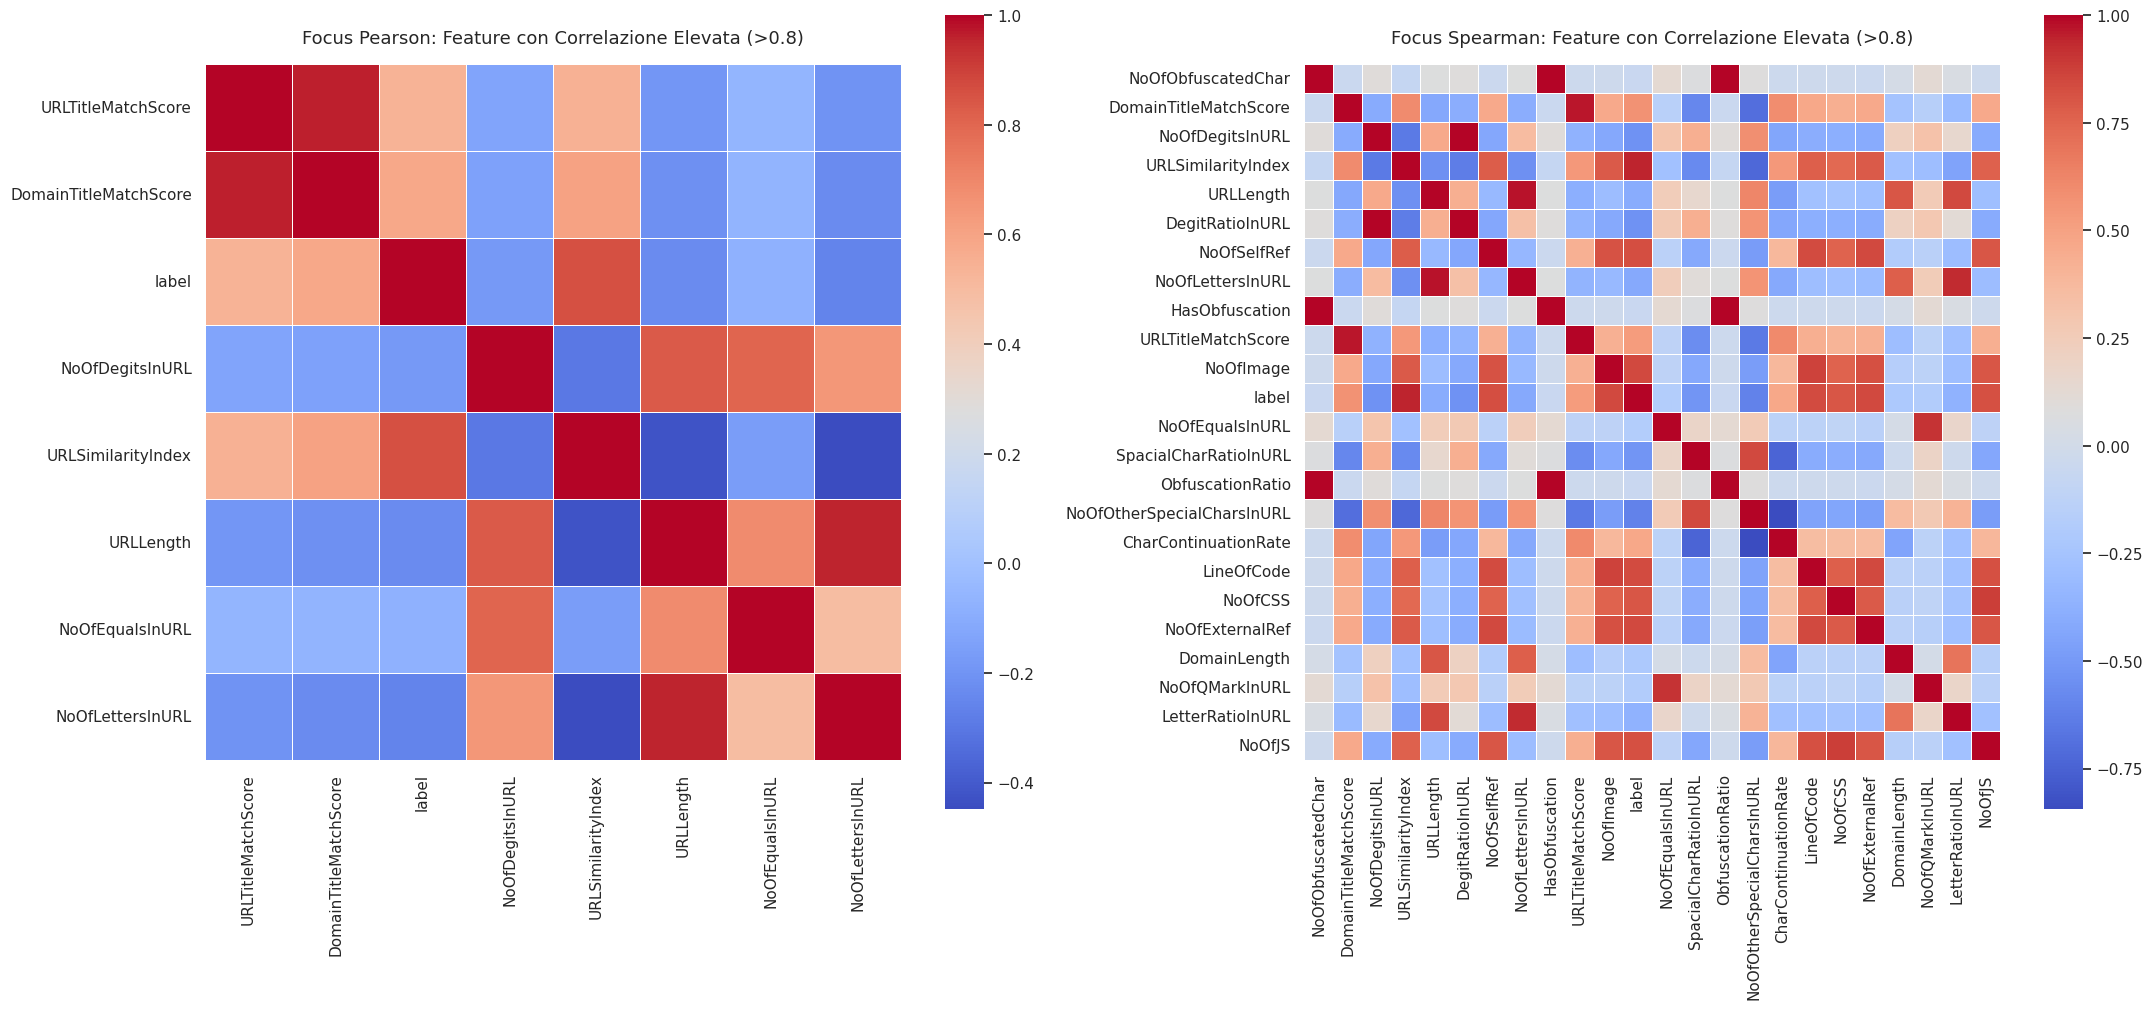

In [ ]:
# Selezioniamo solo le colonne numeriche
df_numeric = df.select_dtypes(include=['int64', 'float64'])
soglia = 0.8

# Prepariamo la figura con 2 sotto-grafici (heatmap) affiancati
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
metodi = ['pearson', 'spearman']

for i, metodo in enumerate(metodi):

    # Calcolo della matrice di correlazione specifica per il metodo
    corr = df_numeric.corr(method=metodo)

    # Prendiamo solo la parte triangolare superiore (senza diagonale)
    corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Estraiamo le coppie che superano la soglia
    coppie_alte = (
        corr_upper.stack()
        .reset_index()
        .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlazione"})
    )
    coppie_alte = coppie_alte[coppie_alte["Correlazione"].abs() > soglia]
    coppie_alte = coppie_alte.sort_values(by="Correlazione", key=abs, ascending=False)

    print(f"Coppie di feature con |correlazione ({metodo})| > {soglia}:\n")
    if not coppie_alte.empty:
        print(coppie_alte.to_string(index=False))
    else:
        print("Nessuna coppia rileva una correlazione così alta con questo metodo.")

    # Prendiamo i nomi unici delle feature che superano la soglia di ridondanza
    features_correlate = list(set(coppie_alte['Feature_1'].tolist() + coppie_alte['Feature_2'].tolist()))

    # Aggiungiamo anche la label per vedere come si rapportano con il target
    if 'label' not in features_correlate and 'label' in df_numeric.columns:
        features_correlate.append('label')

    # Generiamo la heatmap dedicata nel rispettivo riquadro (ax=axes[i])
    if len(features_correlate) > 1: # Evita crash se non ci sono abbastanza feature correlate
        sns.heatmap(
            df_numeric[features_correlate].corr(method=metodo),
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            square=True,
            ax=axes[i]
        )
        axes[i].set_title(f'Focus {metodo.capitalize()}: Feature con Correlazione Elevata (>{soglia})', fontsize=13, pad=15)
    else:
        axes[i].text(0.5, 0.5, f"Nessuna feature oltre la soglia {soglia}\nper il metodo {metodo.capitalize()}",
                     ha='center', va='center', fontsize=12, color='gray')
        axes[i].set_title(f'Focus {metodo.capitalize()}', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

## Preprocessing

### Rimozioni feature

In [ ]:
cols_to_drop = [
    'URLLength', 'URLTitleMatchScore', 'URLSimilarityIndex', 'Domain','URL','TLD', 'Title', 'TLDLegitimateProb', 'NoOfObfuscatedChar', 'HasObfuscation', 'NoOfDegitsInURL', 'NoOfLettersInURL', 'NoOfOtherSpecialCharsInURL'
]
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 42 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DomainLength           235795 non-null  int64  
 1   IsDomainIP             235795 non-null  int64  
 2   CharContinuationRate   235795 non-null  float64
 3   URLCharProb            235795 non-null  float64
 4   TLDLength              235795 non-null  int64  
 5   NoOfSubDomain          235795 non-null  int64  
 6   ObfuscationRatio       235795 non-null  float64
 7   LetterRatioInURL       235795 non-null  float64
 8   DegitRatioInURL        235795 non-null  float64
 9   NoOfEqualsInURL        235795 non-null  int64  
 10  NoOfQMarkInURL         235795 non-null  int64  
 11  NoOfAmpersandInURL     235795 non-null  int64  
 12  SpacialCharRatioInURL  235795 non-null  float64
 13  IsHTTPS                235795 non-null  int64  
 14  LineOfCode             235795 non-nu

### Separazione dataset in dati di training (80%) e di test (20%) e standardizzazione dei dati

In [ ]:
# Separiamo le feature (X) dalla variabile target (y)
X_model = df_cleaned.drop(columns=[target_col])
y_model = df_cleaned[target_col]

# Dividiamo il dataset in training set (80%) e test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)


scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

## Addrestamento Modelli

### Decision Tree

In [ ]:
max_depth = 7
min_samples_split = 2

decisionTree = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42, class_weight='balanced')
decisionTree.fit(X_train, y_train)

# Predizioni sul test set
y_pred_tree = decisionTree.predict(X_test)
y_prob_tree = decisionTree.predict_proba(X_test)[:,1]

Accuracy Decision Tree: 0.9961195105918277
              precision    recall  f1-score   support

           0     0.9962    0.9947    0.9955     20189
           1     0.9961    0.9971    0.9966     26970

    accuracy                         0.9961     47159
   macro avg     0.9961    0.9959    0.9960     47159
weighted avg     0.9961    0.9961    0.9961     47159



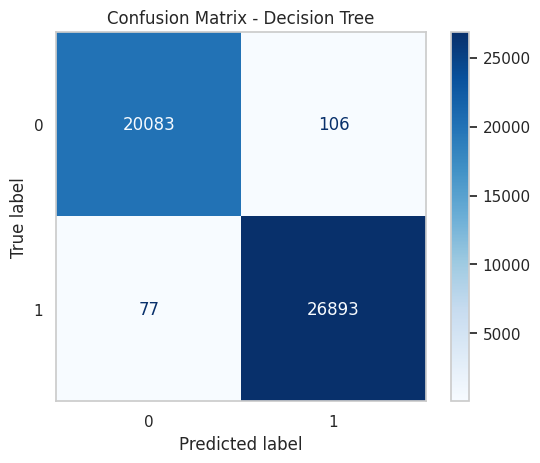

In [ ]:
# Accuratezza
print("Accuracy Decision Tree:", accuracy_score(y_test, y_pred_tree))

# Report completo: precision, recall, f1-score per classe
print(classification_report(y_test, y_pred_tree, zero_division=0, digits= 4))

# Matrice di confusione
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Decision Tree')
plt.grid(False)
plt.show()

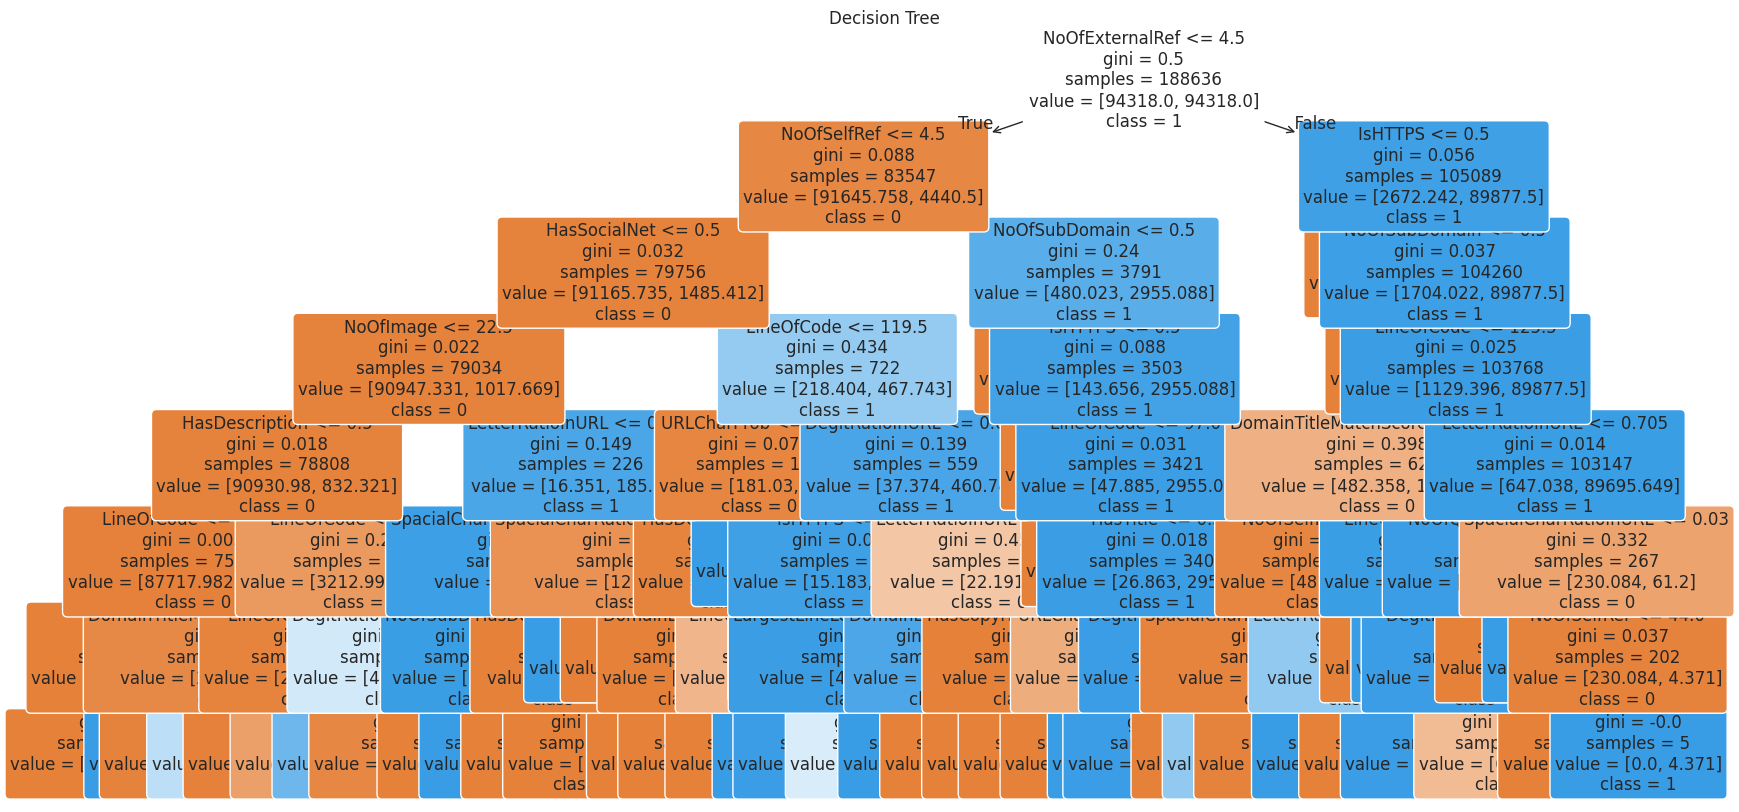

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(decisionTree,
          filled=True,
          feature_names=X_train.columns.tolist(),  # oppure lista manuale dei nomi
          class_names=['0', '1'],
          rounded=True,
          fontsize=12)
plt.title('Decision Tree')
plt.show()

### Neural Network

In [ ]:
def build_nn_model(n_features, X_train, y_train, seed, verbose):
    tf.random.set_seed(seed)
    modelNN = Sequential()
    modelNN.add(Input(shape=(n_features,)))

    modelNN.add(Dense(32, activation='relu'))
    modelNN.add(Dense(16, activation='relu'))
    modelNN.add(Dense(1, activation='sigmoid'))

    # Usiamo TrueNegatives: traccia esattamente quanti '0' (Phishing) vengono indovinati
    modelNN.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy', tf.keras.metrics.TrueNegatives(name='tn')]
    )

    # Monitoriamo i True Negatives sulla validazione per massimizzare la Recall della classe 0
    early_stop = EarlyStopping(
        monitor='val_tn',
        mode='max',
        patience=4,
        restore_best_weights=True
    )

    modelNN.fit(
        X_train, y_train,
        epochs=30,
        batch_size=512,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=verbose
    )

    return modelNN

# Chiamiamo la funzione passando le feature e i dati di train strutturati
n_features = X_train_std.shape[1]
modelNN = build_nn_model(n_features, X_train_std, y_train, 42, 1)

Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9871 - loss: 0.0685 - tn: 63291.0000 - val_accuracy: 0.9969 - val_loss: 0.0106 - val_tn: 16179.0000
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9983 - loss: 0.0064 - tn: 64355.0000 - val_accuracy: 0.9986 - val_loss: 0.0051 - val_tn: 16215.0000
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9990 - loss: 0.0035 - tn: 64414.0000 - val_accuracy: 0.9990 - val_loss: 0.0034 - val_tn: 16223.0000
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9993 - loss: 0.0024 - tn: 64436.0000 - val_accuracy: 0.9993 - val_loss: 0.0026 - val_tn: 16232.0000
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9995 - loss: 0.0019 - tn: 64454.0000 - val_accuracy: 0.9994 - val_loss: 0.0021 - val_tn: 16234.0000
Epoch 6/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9996 - loss: 0.0015 - tn: 64463.0000 - val_accuracy: 0.9996 - val_loss: 0.0018 - val_tn: 16242.0000
Epoc

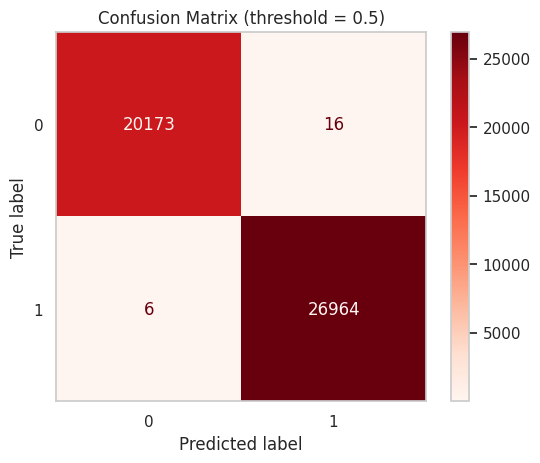

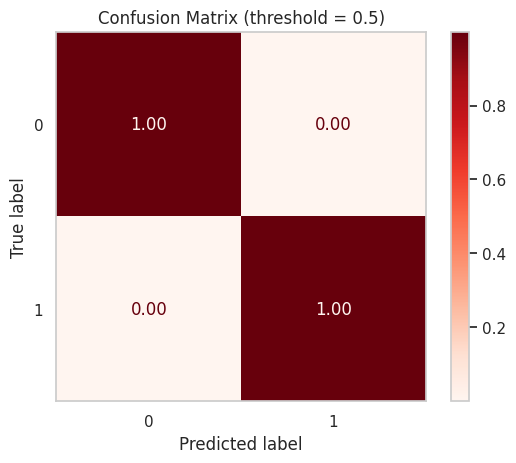

Classification report (threshold=0.5)
              precision    recall  f1-score   support

           0     0.9997    0.9992    0.9995     20189
           1     0.9994    0.9998    0.9996     26970

    accuracy                         0.9995     47159
   macro avg     0.9996    0.9995    0.9995     47159
weighted avg     0.9995    0.9995    0.9995     47159



In [ ]:
# Calcoliamo le predizioni (probabilità) e le classi discrete (0 o 1) con soglia 0.5
y_score = modelNN.predict(X_test_std, verbose=0).ravel()
y_pred_05 = (y_score >= 0.5).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)
cm_normalized = confusion_matrix(y_test, y_pred_05, normalize = 'true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_05)
disp.plot(cmap = 'Reds', values_format='d')
plt.title("Confusion Matrix (threshold = 0.5)")
plt.grid(False)
plt.show()


disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)
disp.plot(cmap = 'Reds', values_format='.2f')
plt.title("Confusion Matrix (threshold = 0.5)")
plt.grid(False)
plt.show()


print("Classification report (threshold=0.5)")
print(classification_report(y_test, y_pred_05, digits=4))

## Tecniche di Sporco

### Missing Data (MCAR)


Viene usata la tecninca MCAR (Missing Completely at Random): la probabilita che un dato diventi nullo è la stessa per ogni singola cella del dataset.  Dato un parametro missing_rate (es. 0.1 = 10%):
Per ogni cella del dataset, si genera un numero casuale tra 0 e 1.
Se quel numero è minore di missing_rate allora quella cella diventa NaN.
Il risultato è che circa il 10% dei valori del dataset sarà mancante, distribuiti uniformemente.

Split 1/10 completato
Split 2/10 completato
Split 3/10 completato
Split 4/10 completato
Split 5/10 completato
Split 6/10 completato
Split 7/10 completato
Split 8/10 completato
Split 9/10 completato
Split 10/10 completato


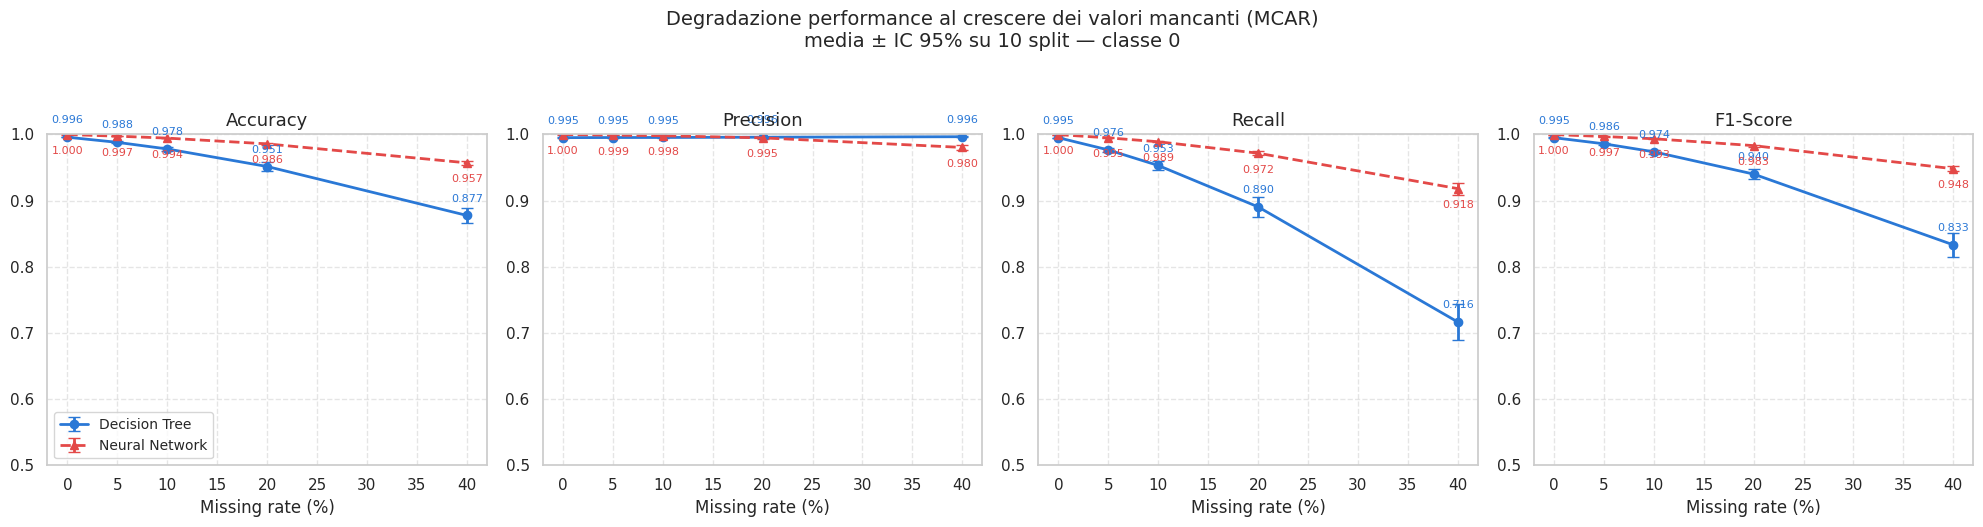

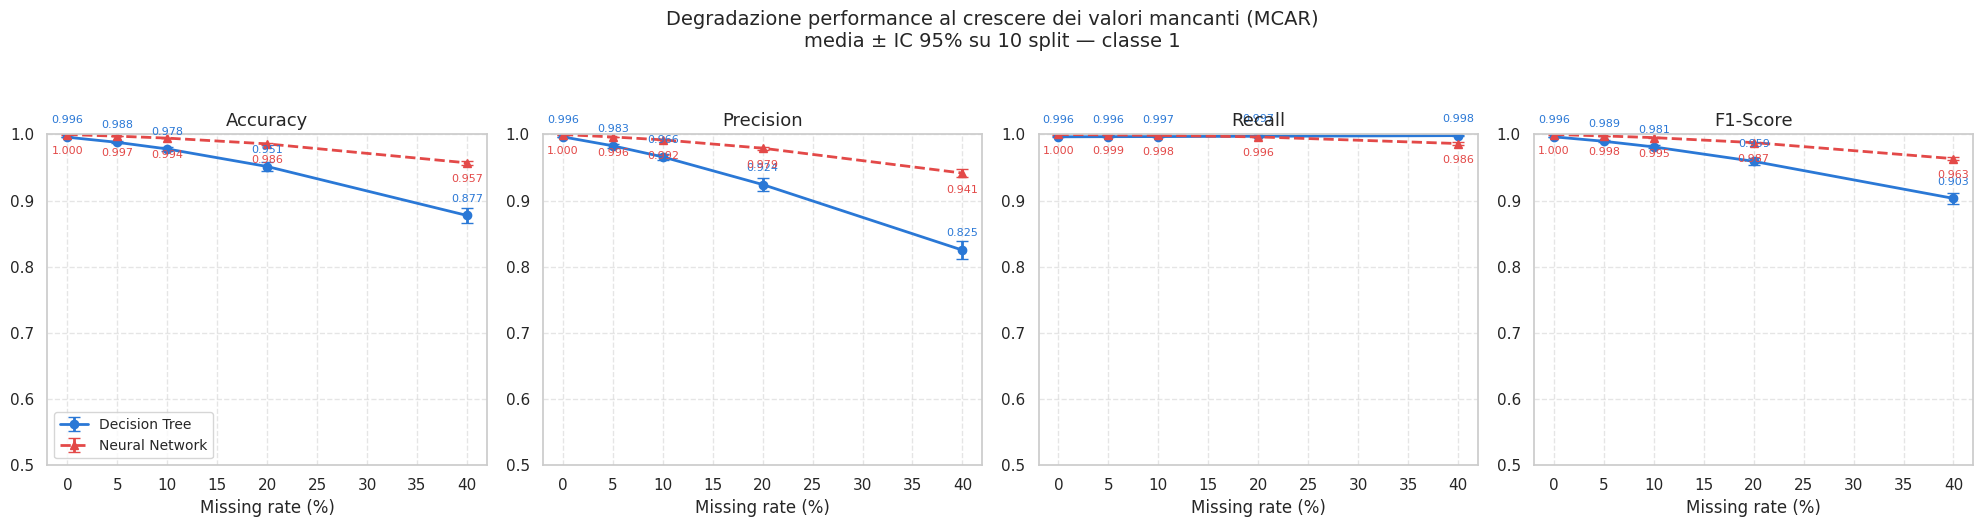

In [ ]:
def add_mcar(X, missing_rate, rng):
    X_missing = X.copy().astype(float)  # NaN richiede float
    # Generazione di numeri casuali, che hanno la stessa forma del dataset X_missing.
    # Grazie a < missing_rate, alla fine ottengo un matrice booleana
    mask = rng.random(X_missing.shape) < missing_rate
    # Sostituisco i valori True della matrice booleana con NaN
    X_missing[mask] = np.nan
    return X_missing

missing_rates = [0.0, 0.05, 0.10, 0.20, 0.40]
N = 10
n_levels = len(missing_rates)

# liste "grezze": un valore per ogni combinazione (split, missing_rate)
acc_dt, prec0_dt, prec1_dt, rec0_dt, rec1_dt, f10_dt, f11_dt = [], [], [], [], [], [], []
acc_nn, prec0_nn, prec1_nn, rec0_nn, rec1_nn, f10_nn, f11_nn = [], [], [], [], [], [], []

for i in range(N):

    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X_model, y_model, test_size=0.2, random_state=i, stratify=y_model
    )

    # Imputer e Scaler riaddestrati su QUESTO train
    imputer_i = SimpleImputer(strategy='median')
    imputer_i.fit(X_train_i)

    scaler_i = StandardScaler()
    X_train_std_i = scaler_i.fit_transform(X_train_i)

    # Decision Tree riaddestrato da zero
    dt_i = clone(decisionTree)
    dt_i.fit(X_train_i, y_train_i)

    nn_i = build_nn_model(X_train_i.shape[1], X_train_std_i, y_train_i, seed=i, verbose=0)

    # Per ogni missing rate, sporco SOLO il test e valuto
    rng = np.random.default_rng(i)
    for rate in missing_rates:
        X_test_mcar = add_mcar(X_test_i, rate, rng)
        X_test_imputed = pd.DataFrame(
            imputer_i.transform(X_test_mcar),
            columns=X_test_i.columns,
            index=X_test_i.index
        )

        # Decision Tree
        y_pred_dt = dt_i.predict(X_test_imputed)
        p_dt, r_dt, f_dt, _ = precision_recall_fscore_support(
            y_test_i, y_pred_dt, labels=[0, 1], zero_division=0
        )
        acc_dt.append(accuracy_score(y_test_i, y_pred_dt))
        prec0_dt.append(p_dt[0]); prec1_dt.append(p_dt[1])
        rec0_dt.append(r_dt[0]);  rec1_dt.append(r_dt[1])
        f10_dt.append(f_dt[0]);   f11_dt.append(f_dt[1])

        # Neural Network
        X_test_imputed_std = scaler_i.transform(X_test_imputed)
        y_score_nn = nn_i.predict(X_test_imputed_std, verbose=0).ravel()
        y_pred_nn = (y_score_nn >= 0.5).astype(int)
        p_nn, r_nn, f_nn, _ = precision_recall_fscore_support(
            y_test_i, y_pred_nn, labels=[0, 1], zero_division=0
        )
        acc_nn.append(accuracy_score(y_test_i, y_pred_nn))
        prec0_nn.append(p_nn[0]); prec1_nn.append(p_nn[1])
        rec0_nn.append(r_nn[0]);  rec1_nn.append(r_nn[1])
        f10_nn.append(f_nn[0]);   f11_nn.append(f_nn[1])

    print(f"Split {i+1}/{N} completato")

def avg_ci(val, N, n_levels):
    val = np.array(val).reshape(N, n_levels)
    media = val.mean(axis=0)
    t_crit = t_dist.ppf(0.975, df=N-1)  # ≈ 2.776 per N=5
    ic = t_crit * val.std(axis=0, ddof=1) / np.sqrt(N)
    return media, ic


def plot_metrics_per_class(classe, nome_classe, dt_lists, nn_lists):
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    x = [r * 100 for r in missing_rates]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i, ax in enumerate(axes):
        m_dt, ci_dt = avg_ci(dt_lists[i], N, n_levels)
        m_nn, ci_nn = avg_ci(nn_lists[i], N, n_levels)

        ax.errorbar(x, m_dt, yerr=ci_dt, marker='o', color='#2a78d6',
                    linewidth=2, capsize=4, label='Decision Tree')
        ax.errorbar(x, m_nn, yerr=ci_nn, marker='^', linestyle='--', color='#e34948',
                    linewidth=2, capsize=4, label='Neural Network')

        for xv, yv in zip(x, m_dt):
            ax.annotate(f"{yv:.3f}", (xv, yv), textcoords="offset points",
                        xytext=(0, 10), ha='center', fontsize=8, color='#2a78d6')
        for xv, yv in zip(x, m_nn):
            ax.annotate(f"{yv:.3f}", (xv, yv), textcoords="offset points",
                        xytext=(0, -14), ha='center', fontsize=8, color='#e34948')

        ax.set_title(f'{metric_names[i]}', fontsize=13)
        ax.set_xlabel('Missing rate (%)')
        ax.set_ylim(0.5, 1.0)
        ax.grid(True, ls='--', alpha=0.5)

    axes[0].legend(fontsize=10)
    plt.suptitle(f'Degradazione performance al crescere dei valori mancanti (MCAR)\n'
                 f'media ± IC 95% su {N} split — {nome_classe}', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig(f'performance_mcar_classe_{classe}.pdf', bbox_inches='tight')
    plt.show()


# classe 0 Phishing
plot_metrics_per_class(0, "classe 0",
    [acc_dt, prec0_dt, rec0_dt, f10_dt],
    [acc_nn, prec0_nn, rec0_nn, f10_nn])

# classe 1 Legittimo
plot_metrics_per_class(1, "classe 1",
    [acc_dt, prec1_dt, rec1_dt, f11_dt],
    [acc_nn, prec1_nn, rec1_nn, f11_nn])

### Feature Occlusion

#### Funzioni di utility

In [ ]:
metrics = ['accuracy', 'recall_0', 'precision_0', 'f1_0',
           'accuracy', 'recall_1', 'precision_1', 'f1_1']

titles  = ['Accuracy', 'Recall (Phishing)', 'Precision (Phishing)', 'F1 (Phishing)',
           'Accuracy', 'Recall (Legittimo)', 'Precision (Legittimo)', 'F1 (Legittimo)']

TOP_N = 10
metrics_base = ['accuracy', 'precision_0', 'precision_1', 'recall_0', 'recall_1', 'f1_0', 'f1_1']
feature_names = X_model.columns.tolist()

sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

def Elabora_Risultati_Ablation(metriche_accumulate, feature_names, metrics_base):
    risultati = {'feature_rimossa': []}
    for m in metrics_base:
        risultati[m], risultati[f'{m}_std'] = [], []
        risultati[f'drop_{m}'], risultati[f'drop_{m}_std'] = [], []
        risultati[f'pvalue_{m}'] = []

    baseline_vals = metriche_accumulate['nessuna (baseline)']
    chiavi_report = ['nessuna (baseline)'] + feature_names
    k = len(baseline_vals[metrics_base[0]])

    for nome_elemento in chiavi_report:
        risultati['feature_rimossa'].append(nome_elemento)
        vals = metriche_accumulate[nome_elemento]

        for m in metrics_base:
            risultati[m].append(np.mean(vals[m]))
            risultati[f'{m}_std'].append(np.std(vals[m]))

            if nome_elemento == 'nessuna (baseline)':
                risultati[f'drop_{m}'].append(0.0)
                risultati[f'drop_{m}_std'].append(0.0)
                risultati[f'pvalue_{m}'].append(np.nan)
            else:
                drop_per_split = np.array(baseline_vals[m]) - np.array(vals[m])
                mean_drop = np.mean(drop_per_split)

                risultati[f'drop_{m}'].append(mean_drop)
                risultati[f'drop_{m}_std'].append(np.std(drop_per_split))

                if np.allclose(drop_per_split, 0):
                    pval = 1.0
                else:
                    std_drop = np.std(drop_per_split, ddof=1)
                    if std_drop == 0:
                        pval = 0.0
                    else:
                        _, pval = ttest_rel(baseline_vals[m], vals[m])

                risultati[f'pvalue_{m}'].append(pval)

    return pd.DataFrame(risultati)

def get_color(drop, pvalue, alpha=0.05):
    if pvalue >= alpha:
        return '#b0b0b0'
    if drop >= 0.04: return '#e34948'
    if drop >= 0.02: return '#eda100'
    return '#2a78d6'

patches_legenda = [
    mpatches.Patch(color='#e34948', label='drop > 4 pp — critica (p<0.05)'),
    mpatches.Patch(color='#eda100', label='drop 2–4 pp — rilevante (p<0.05)'),
    mpatches.Patch(color='#2a78d6', label='drop < 2 pp — marginale (p<0.05)'),
    mpatches.Patch(color='#b0b0b0', label='non significativo (p≥0.05)'),
]

def plot_ablation(df_ablation, metrics, titles, top_n, titolo_modello, filename):
    df_plot = df_ablation.loc[df_ablation['feature_rimossa'] != 'nessuna (baseline)'].copy()
    baselines = {m: df_ablation.loc[df_ablation['feature_rimossa'] == 'nessuna (baseline)', m].values[0] for m in metrics}

    max_drop_global = 0
    for metric in metrics:
        df_sorted = df_plot.sort_values(f'drop_{metric}', ascending=True).tail(top_n)

        current_max = np.max(df_sorted[f'drop_{metric}'] * 100 + df_sorted[f'drop_{metric}_std'] * 100)
        if current_max > max_drop_global:
            max_drop_global = current_max

    xlim_max = float(np.ceil(max_drop_global / 5) * 5)
    if xlim_max < 10: xlim_max = 10.0

    fig, axes = plt.subplots(4, 2, figsize=(15, top_n * 0.60 + 3), sharey=False)
    axes = axes.flatten()

    for ax, metric, title in zip(axes, metrics, titles):
        df_sorted = df_plot.sort_values(f'drop_{metric}', ascending=True).tail(top_n)
        colors = [get_color(d, p) for d, p in zip(df_sorted[f'drop_{metric}'], df_sorted[f'pvalue_{metric}'])]
        baseline = baselines[metric]

        ax.barh(df_sorted['feature_rimossa'],
                df_sorted[f'drop_{metric}'] * 100,
                xerr=df_sorted[f'drop_{metric}_std'] * 100,
                color=colors, height=0.65,
                error_kw={'elinewidth': 1, 'capsize': 3, 'ecolor': '#444'})

        ax.set_xlim(0, xlim_max)

        ax.set_title(f'{title}  (baseline = {baseline:.3f})', fontsize=12, fontweight='500', pad=8)
        ax.set_xlabel('drop vs baseline (pp)', fontsize=10, color='gray')
        ax.xaxis.set_major_formatter(lambda x, _: f'−{x:.1f}pp')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(axis='x', linestyle=':', alpha=0.4, color='gray')

    fig.legend(handles=patches_legenda, fontsize=10, frameon=False, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'Occlusion study — {titolo_modello} (Stratified 10-Repeated Hold-Out)', fontsize=15, fontweight='500', y=1.02)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

#### Decision Tree

In [ ]:
decisionTree = DecisionTreeClassifier(max_depth=7, min_samples_split=2, random_state=42, class_weight='balanced')
metriche_accumulate_tree = {k: {m: [] for m in metrics_base} for k in ['nessuna (baseline)'] + feature_names}

for fold, (train_idx, test_idx) in enumerate(sss.split(X_model, y_model), 1):
    print(f"Elaborazione Split Stratificato {fold}/10...")
    X_train_sp, X_test_sp = X_model.iloc[train_idx], X_model.iloc[test_idx]
    y_train_sp, y_test_sp = y_model.iloc[train_idx], y_model.iloc[test_idx]

    decisionTree.fit(X_train_sp, y_train_sp)

    y_pred_base = decisionTree.predict(X_test_sp)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_sp, y_pred_base, labels=[0, 1], zero_division=0)
    metriche_accumulate_tree['nessuna (baseline)']['accuracy'].append(accuracy_score(y_test_sp, y_pred_base))
    metriche_accumulate_tree['nessuna (baseline)']['precision_0'].append(prec[0])
    metriche_accumulate_tree['nessuna (baseline)']['precision_1'].append(prec[1])
    metriche_accumulate_tree['nessuna (baseline)']['recall_0'].append(rec[0])
    metriche_accumulate_tree['nessuna (baseline)']['recall_1'].append(rec[1])
    metriche_accumulate_tree['nessuna (baseline)']['f1_0'].append(f1[0])
    metriche_accumulate_tree['nessuna (baseline)']['f1_1'].append(f1[1])

    for col in feature_names:
        X_test_ablated = X_test_sp.copy()
        # neutralizzazione feature
        X_test_ablated[col] = X_train_sp[col].mean()

        y_pred_ablated = decisionTree.predict(X_test_ablated)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test_sp, y_pred_ablated, labels=[0, 1], zero_division=0)

        metriche_accumulate_tree[col]['accuracy'].append(accuracy_score(y_test_sp, y_pred_ablated))
        metriche_accumulate_tree[col]['precision_0'].append(prec[0])
        metriche_accumulate_tree[col]['precision_1'].append(prec[1])
        metriche_accumulate_tree[col]['recall_0'].append(rec[0])
        metriche_accumulate_tree[col]['recall_1'].append(rec[1])
        metriche_accumulate_tree[col]['f1_0'].append(f1[0])
        metriche_accumulate_tree[col]['f1_1'].append(f1[1])

Elaborazione Split Stratificato 1/10...
Elaborazione Split Stratificato 2/10...
Elaborazione Split Stratificato 3/10...
Elaborazione Split Stratificato 4/10...
Elaborazione Split Stratificato 5/10...
Elaborazione Split Stratificato 6/10...
Elaborazione Split Stratificato 7/10...
Elaborazione Split Stratificato 8/10...
Elaborazione Split Stratificato 9/10...
Elaborazione Split Stratificato 10/10...


#### Neural Network

In [ ]:
metriche_accumulate_nn = {k: {m: [] for m in metrics_base} for k in ['nessuna (baseline)'] + feature_names}

for fold, (train_idx, test_idx) in enumerate(sss.split(X_model, y_model), 1):
    print(f"Elaborazione Split Stratificato {fold}/10...")
    X_train_sp, X_test_sp = X_model.iloc[train_idx].copy(), X_model.iloc[test_idx].copy()
    y_train_sp, y_test_sp = y_model.iloc[train_idx], y_model.iloc[test_idx]

    scaler = StandardScaler()
    X_train_std_sp = scaler.fit_transform(X_train_sp)
    X_test_std_sp = scaler.transform(X_test_sp)

    modelNN = build_nn_model(X_train_std_sp.shape[1], X_train_std_sp, y_train_sp, seed = fold, verbose=0)

    y_prob_base = modelNN.predict(X_test_std_sp, batch_size=2048, verbose=0)
    y_pred_base = (y_prob_base > 0.5).astype(int).ravel()

    prec, rec, f1, _ = precision_recall_fscore_support(y_test_sp, y_pred_base, labels=[0, 1], zero_division=0)
    metriche_accumulate_nn['nessuna (baseline)']['accuracy'].append(accuracy_score(y_test_sp, y_pred_base))
    metriche_accumulate_nn['nessuna (baseline)']['precision_0'].append(prec[0])
    metriche_accumulate_nn['nessuna (baseline)']['precision_1'].append(prec[1])
    metriche_accumulate_nn['nessuna (baseline)']['recall_0'].append(rec[0])
    metriche_accumulate_nn['nessuna (baseline)']['recall_1'].append(rec[1])
    metriche_accumulate_nn['nessuna (baseline)']['f1_0'].append(f1[0])
    metriche_accumulate_nn['nessuna (baseline)']['f1_1'].append(f1[1])

    medie_train = X_train_std_sp.mean(axis=0)
    for col_idx, col_name in enumerate(feature_names):
        X_test_ablated = X_test_std_sp.copy()
        X_test_ablated[:, col_idx] = medie_train[col_idx]

        y_prob_ablated = modelNN.predict(X_test_ablated, batch_size=2048, verbose=0)
        y_pred_ablated = (y_prob_ablated > 0.5).astype(int).ravel()

        prec, rec, f1, _ = precision_recall_fscore_support(y_test_sp, y_pred_ablated, labels=[0, 1], zero_division=0)
        metriche_accumulate_nn[col_name]['accuracy'].append(accuracy_score(y_test_sp, y_pred_ablated))
        metriche_accumulate_nn[col_name]['precision_0'].append(prec[0])
        metriche_accumulate_nn[col_name]['precision_1'].append(prec[1])
        metriche_accumulate_nn[col_name]['recall_0'].append(rec[0])
        metriche_accumulate_nn[col_name]['recall_1'].append(rec[1])
        metriche_accumulate_nn[col_name]['f1_0'].append(f1[0])
        metriche_accumulate_nn[col_name]['f1_1'].append(f1[1])

Elaborazione Split Stratificato 1/10...
Elaborazione Split Stratificato 2/10...
Elaborazione Split Stratificato 3/10...
Elaborazione Split Stratificato 4/10...
Elaborazione Split Stratificato 5/10...
Elaborazione Split Stratificato 6/10...
Elaborazione Split Stratificato 7/10...
Elaborazione Split Stratificato 8/10...
Elaborazione Split Stratificato 9/10...
Elaborazione Split Stratificato 10/10...


#### Grafici DT e NN

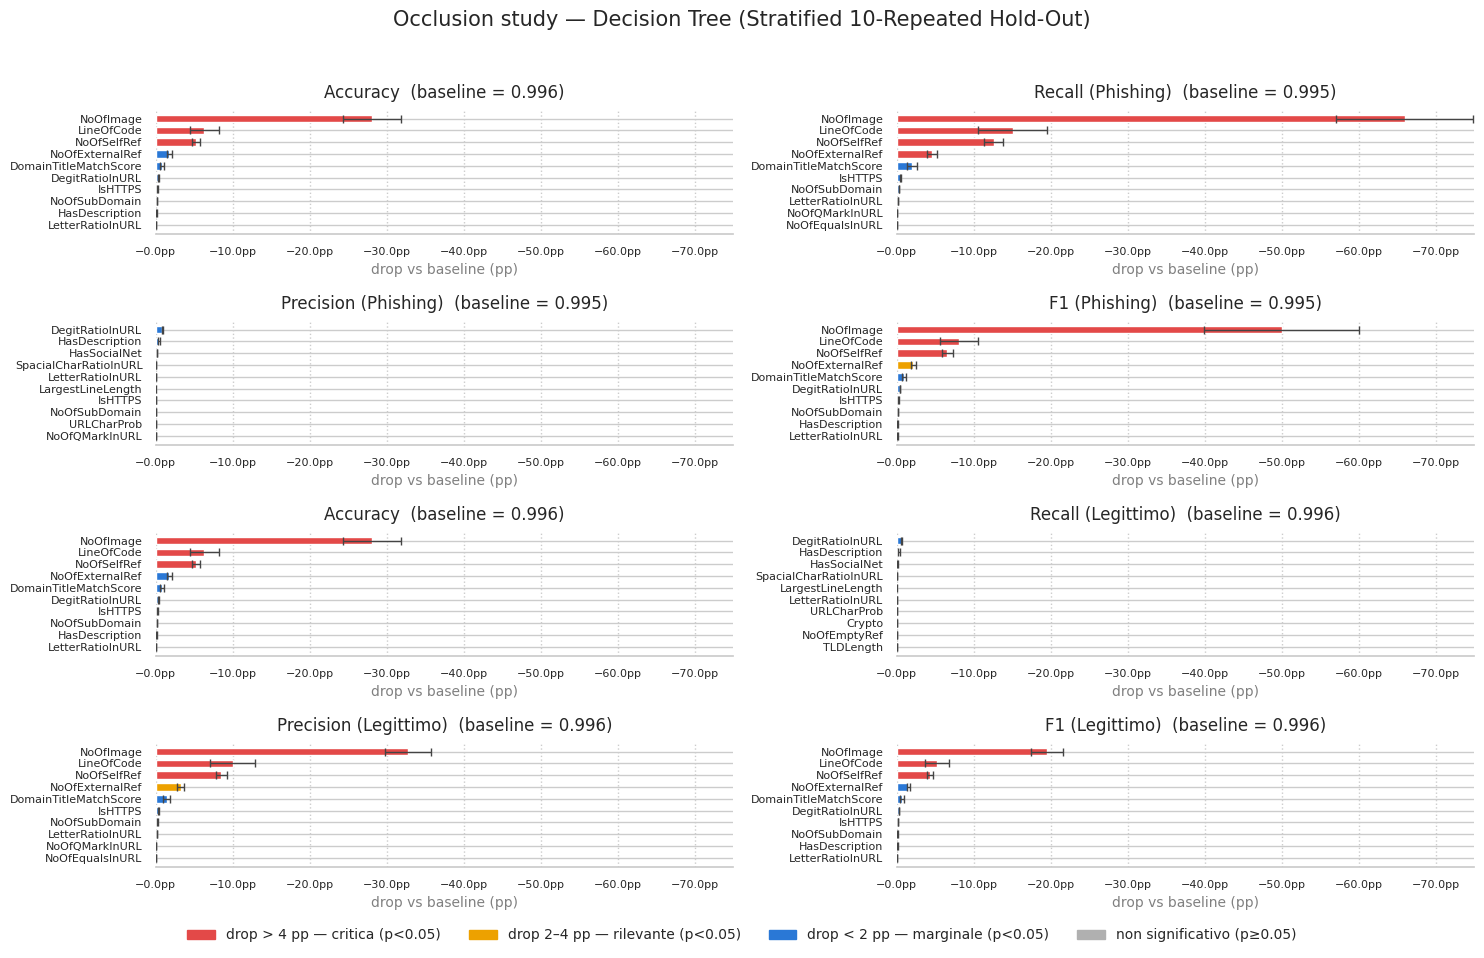

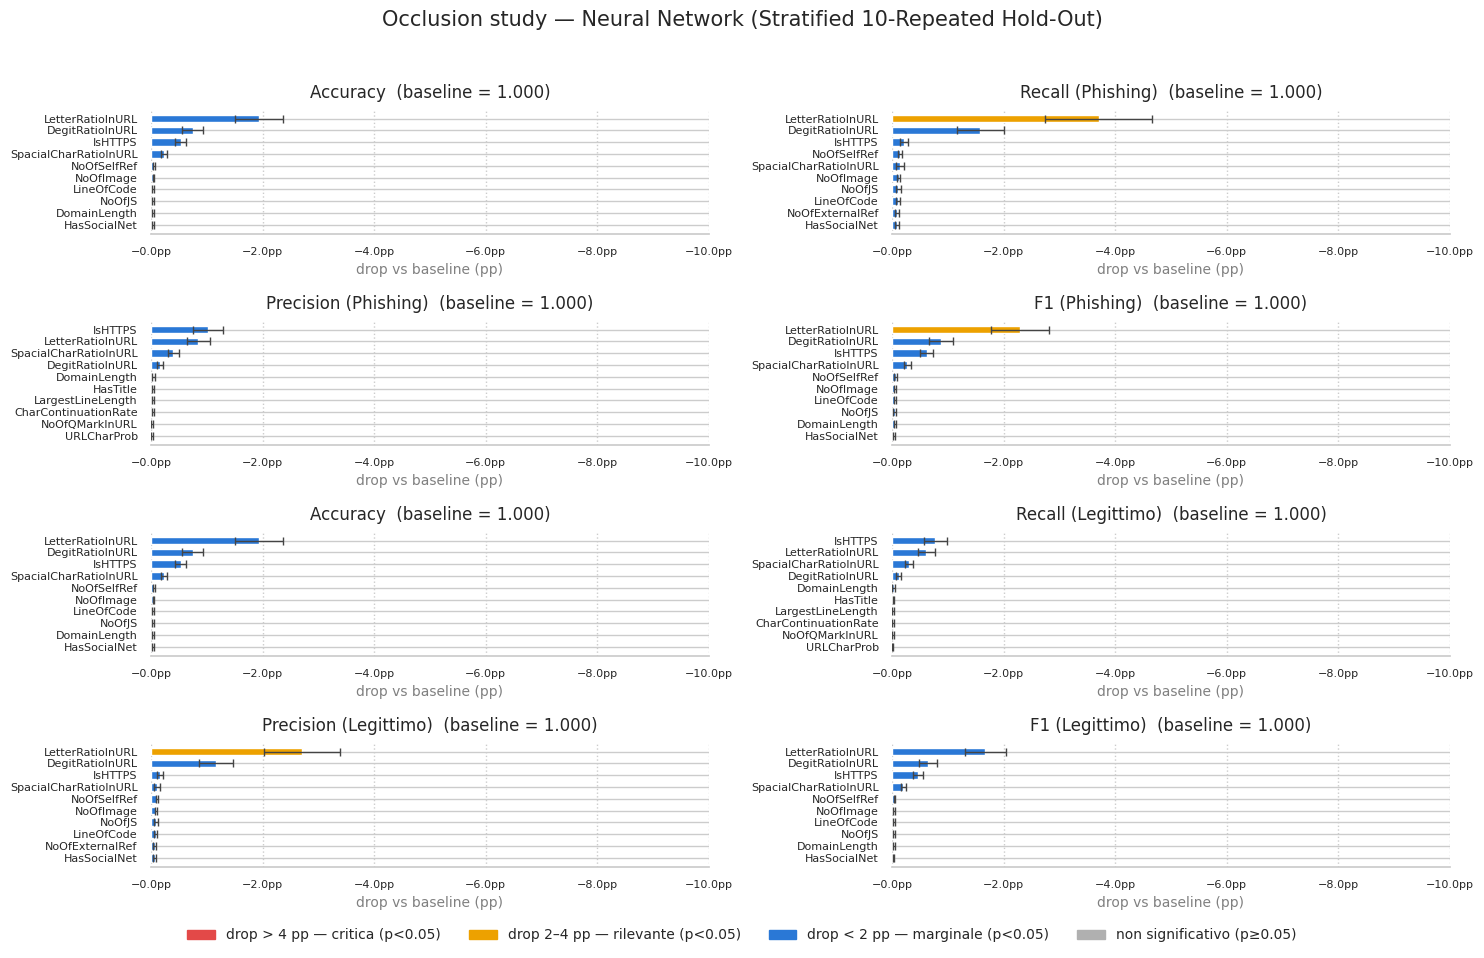


Top 5 Feature critiche per il Decision Tree
      feature_rimossa  drop_recall_0  pvalue_recall_0
            NoOfImage       0.659711     3.599838e-09
           LineOfCode       0.150874     3.319147e-06
          NoOfSelfRef       0.125905     2.494064e-10
      NoOfExternalRef       0.045564     8.116297e-09
DomainTitleMatchScore       0.019610     4.980752e-06
              IsHTTPS       0.005018     6.767227e-09

Top 5 Feature critiche per il Neural Network
      feature_rimossa  drop_recall_0  pvalue_recall_0
     LetterRatioInURL       0.037015     1.020204e-06
      DegitRatioInURL       0.015801     1.299925e-06
              IsHTTPS       0.002130     5.574906e-06
          NoOfSelfRef       0.001481     2.845632e-07
SpacialCharRatioInURL       0.001476     1.688620e-04
            NoOfImage       0.001184     3.110804e-07


In [ ]:
# Grafico Decision Tree
df_ablation_tree = Elabora_Risultati_Ablation(metriche_accumulate_tree, feature_names, metrics_base)
plot_ablation(df_ablation_tree, metrics, titles, TOP_N, 'Decision Tree', 'ablation_dt_4metrics.pdf')

# Grafico Neural Network
df_ablation_nn = Elabora_Risultati_Ablation(metriche_accumulate_nn, feature_names, metrics_base)
plot_ablation(df_ablation_nn, metrics, titles, TOP_N, 'Neural Network', 'ablation_nn_4metrics.pdf')

print("\nTop 5 Feature critiche per il Decision Tree")
print(df_ablation_tree.sort_values('drop_recall_0', ascending=False)[['feature_rimossa', 'drop_recall_0', 'pvalue_recall_0']].head(6).to_string(index=False))

print("\nTop 5 Feature critiche per il Neural Network")
print(df_ablation_nn.sort_values('drop_recall_0', ascending=False)[['feature_rimossa', 'drop_recall_0', 'pvalue_recall_0']].head(6).to_string(index=False))

### Targeted Feature Noise

In [ ]:
def add_gaussian_noise(feature, noise_level, rng, std):
    return feature + rng.normal(loc=0.0, scale=noise_level * std, size=len(feature))

def add_uniform_noise(feature, noise_level, rng, std):
    amplitude = noise_level * std
    return feature + rng.uniform(-amplitude, amplitude, size=len(feature))

 # riporta i valori rumorosi in un range plausibile per il tipo di feature
def clip_to_domain(col_name, values, count_features, ratio_features):
    if col_name in count_features:
        return np.clip(np.round(values), 0, None)
    elif col_name in ratio_features:
        return np.clip(values, 0, 1)
    return values

def calculate_ic95(vals):
    vals = np.asarray(vals)
    n = len(vals)
    if n <= 1:
        return 0.0
    t_crit = t_dist.ppf(0.975, df=n - 1)
    return t_crit * vals.std(ddof=1) / np.sqrt(n)

N = 10
noise_levels_targeted = [0.0, 0.5, 1.0, 2.0, 5.0]

#### Decision Tree

In [ ]:
# feature su cui inietteremo rumore e livelli di rumore da testare
# abbiamo usato quelle risultanti dall'analisi sull'ablation
targeted_features_dt = ['NoOfImage', 'LineOfCode', 'NoOfSelfRef', 'NoOfExternalRef']
count_features_dt = targeted_features_dt
ratio_features_dt = []  # nessuna feature "ratio" in questo set


risultati_targeted_dt = []  # qui accumuliamo una riga per ogni (split, noise_type, noise_level)

for i in range(N):
  # split diverso ad ogni iterazione, così le metriche non dipendono da un singolo campionamento
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X_model, y_model, test_size=0.2, random_state=i, stratify=y_model
    )

    # albero riaddestrato da zero su questo split, non riusiamo mai lo stesso modello tra split diversi
    dt_i = clone(decisionTree)
    dt_i.fit(X_train_i, y_train_i)

    # std calcolata una sola volta sul train dello split, così il rumore resta coerente
    # tra tutte le combinazioni noise_type/noise_level
    feature_stds_i = X_train_i[targeted_features_dt].std()

    rng_targeted = np.random.default_rng(i)  # seed legato allo split, non più fisso a 42

    # testiamo entrambi i tipi di rumore su tutti i livelli, per ogni split e modello
    for noise_type, noise_func in [('gaussian', add_gaussian_noise), ('uniform', add_uniform_noise)]:
        for level in noise_levels_targeted:
            X_test_targeted_noisy = X_test_i.copy()

            # sporchiamo solo le feature target, ognuna con la sua std
            for col in targeted_features_dt:
                # std della colonna passata a parte, cosi il rumore scala in base alla variabilita della feature
                noisy_col = noise_func(
                    X_test_targeted_noisy[col].values, level, rng_targeted, feature_stds_i[col]
                )
                # riportiamo i valori in un range plausibile prima di riscrivere la colonna
                X_test_targeted_noisy[col] = clip_to_domain(col, noisy_col, count_features_dt, ratio_features_dt)

            y_pred_targeted = dt_i.predict(X_test_targeted_noisy)
            prec, rec, f1, _ = precision_recall_fscore_support(
                y_test_i, y_pred_targeted, labels=[0, 1], zero_division=0
            )

            # salviamo split, tipo/livello di rumore e tutte le metriche in un'unica riga
            risultati_targeted_dt.append({
                'split': i, 'noise_type': noise_type, 'noise_level': level,
                'accuracy': accuracy_score(y_test_i, y_pred_targeted),
                'precision_0': prec[0], 'precision_1': prec[1],
                'recall_0': rec[0], 'recall_1': rec[1],
                'f1_0': f1[0], 'f1_1': f1[1],
            })

    print(f"Split {i+1}/{N} completato (DT targeted)")

# risultati grezzi: una riga per ogni combinazione split x noise_type x noise_level
df_risultati_targeted_dt_raw = pd.DataFrame(risultati_targeted_dt)

Split 1/10 completato (DT targeted)
Split 2/10 completato (DT targeted)
Split 3/10 completato (DT targeted)
Split 4/10 completato (DT targeted)
Split 5/10 completato (DT targeted)
Split 6/10 completato (DT targeted)
Split 7/10 completato (DT targeted)
Split 8/10 completato (DT targeted)
Split 9/10 completato (DT targeted)
Split 10/10 completato (DT targeted)


#### Neural Network

In [ ]:
# feature target per la Neural Network, diversa da quella usata per il Decision Tree
# abbiamo usato quelle risultanti dall'analisi sull'ablation
target_features_nn = ['LetterRatioInURL']
count_features_nn = []  # nessuna feature di conteggio in questo set
ratio_features_nn = target_features_nn  # LetterRatioInURL è un rapporto in [0,1]

risultati_targeted_nn = []

for i in range(N):
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X_model, y_model, test_size=0.2, random_state=i, stratify=y_model
    )

    # scaler riaddestrato su questo split, la NN lavora su dati standardizzati
    scaler_i = StandardScaler()
    X_train_std_i = scaler_i.fit_transform(X_train_i)

    # nuovo modello ad ogni split per evitare che pesi di run precedenti influenzino il training

    nn_i = build_nn_model(X_train_i.shape[1], X_train_std_i, y_train_i, seed=i, verbose=0)

    # std calcolata sul train grezzo (pre-scaling), coerente con lo spazio in cui iniettiamo il rumore
    feature_stds_i = X_train_i[target_features_nn].std()

    rng_targeted_nn = np.random.default_rng(i)

    # per ogni combinazione tipo di rumore / livello, perturbiamo solo le feature target
    for noise_type, noise_func in [('gaussian', add_gaussian_noise), ('uniform', add_uniform_noise)]:
        for level in noise_levels_targeted:
            X_test_targeted_noisy_raw = X_test_i.copy()
            for col in target_features_nn:
                noisy_col = noise_func(
                    X_test_targeted_noisy_raw[col].values, level, rng_targeted_nn, feature_stds_i[col]
                )
                X_test_targeted_noisy_raw[col] = clip_to_domain(col, noisy_col, count_features_nn, ratio_features_nn)

            # applichiamo lo stesso scaler fittato sul train, coerente col preprocessing della NN
            X_test_targeted_noisy_std = scaler_i.transform(X_test_targeted_noisy_raw)
            y_prob_targeted = nn_i.predict(X_test_targeted_noisy_std, verbose=0)
            y_pred_targeted = (y_prob_targeted > 0.5).astype(int).ravel() # soglia 0.5 per la classificazione binaria

            prec, rec, f1, _ = precision_recall_fscore_support(
                y_test_i, y_pred_targeted, labels=[0, 1], zero_division=0
            )

            # salviamo le metriche per classe
            risultati_targeted_nn.append({
                'split': i, 'noise_type': noise_type, 'noise_level': level,
                'accuracy': accuracy_score(y_test_i, y_pred_targeted),
                'precision_0': prec[0], 'precision_1': prec[1],
                'recall_0': rec[0], 'recall_1': rec[1],
                'f1_0': f1[0], 'f1_1': f1[1],
            })

    print(f"Split {i+1}/{N} completato (NN targeted)")

df_risultati_targeted_nn_raw = pd.DataFrame(risultati_targeted_nn)

Split 1/10 completato (NN targeted)
Split 2/10 completato (NN targeted)
Split 3/10 completato (NN targeted)
Split 4/10 completato (NN targeted)
Split 5/10 completato (NN targeted)
Split 6/10 completato (NN targeted)
Split 7/10 completato (NN targeted)
Split 8/10 completato (NN targeted)
Split 9/10 completato (NN targeted)
Split 10/10 completato (NN targeted)


#### Risultati

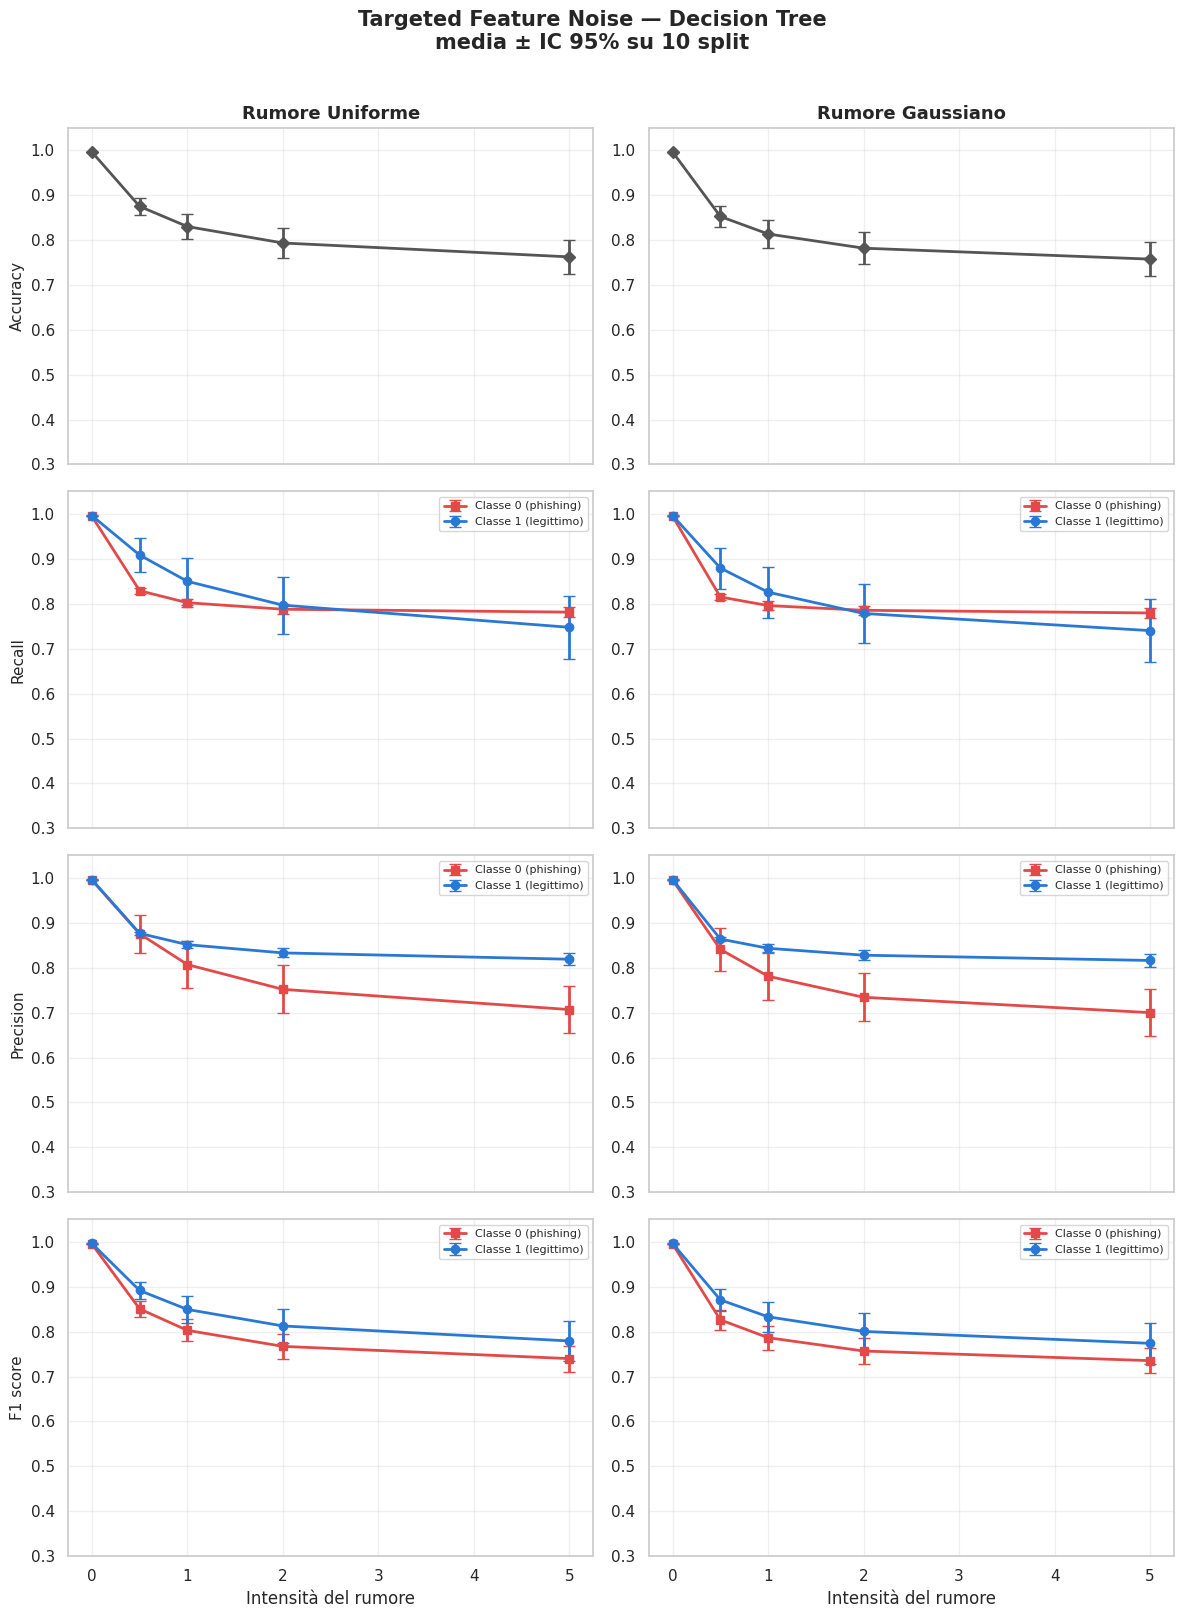

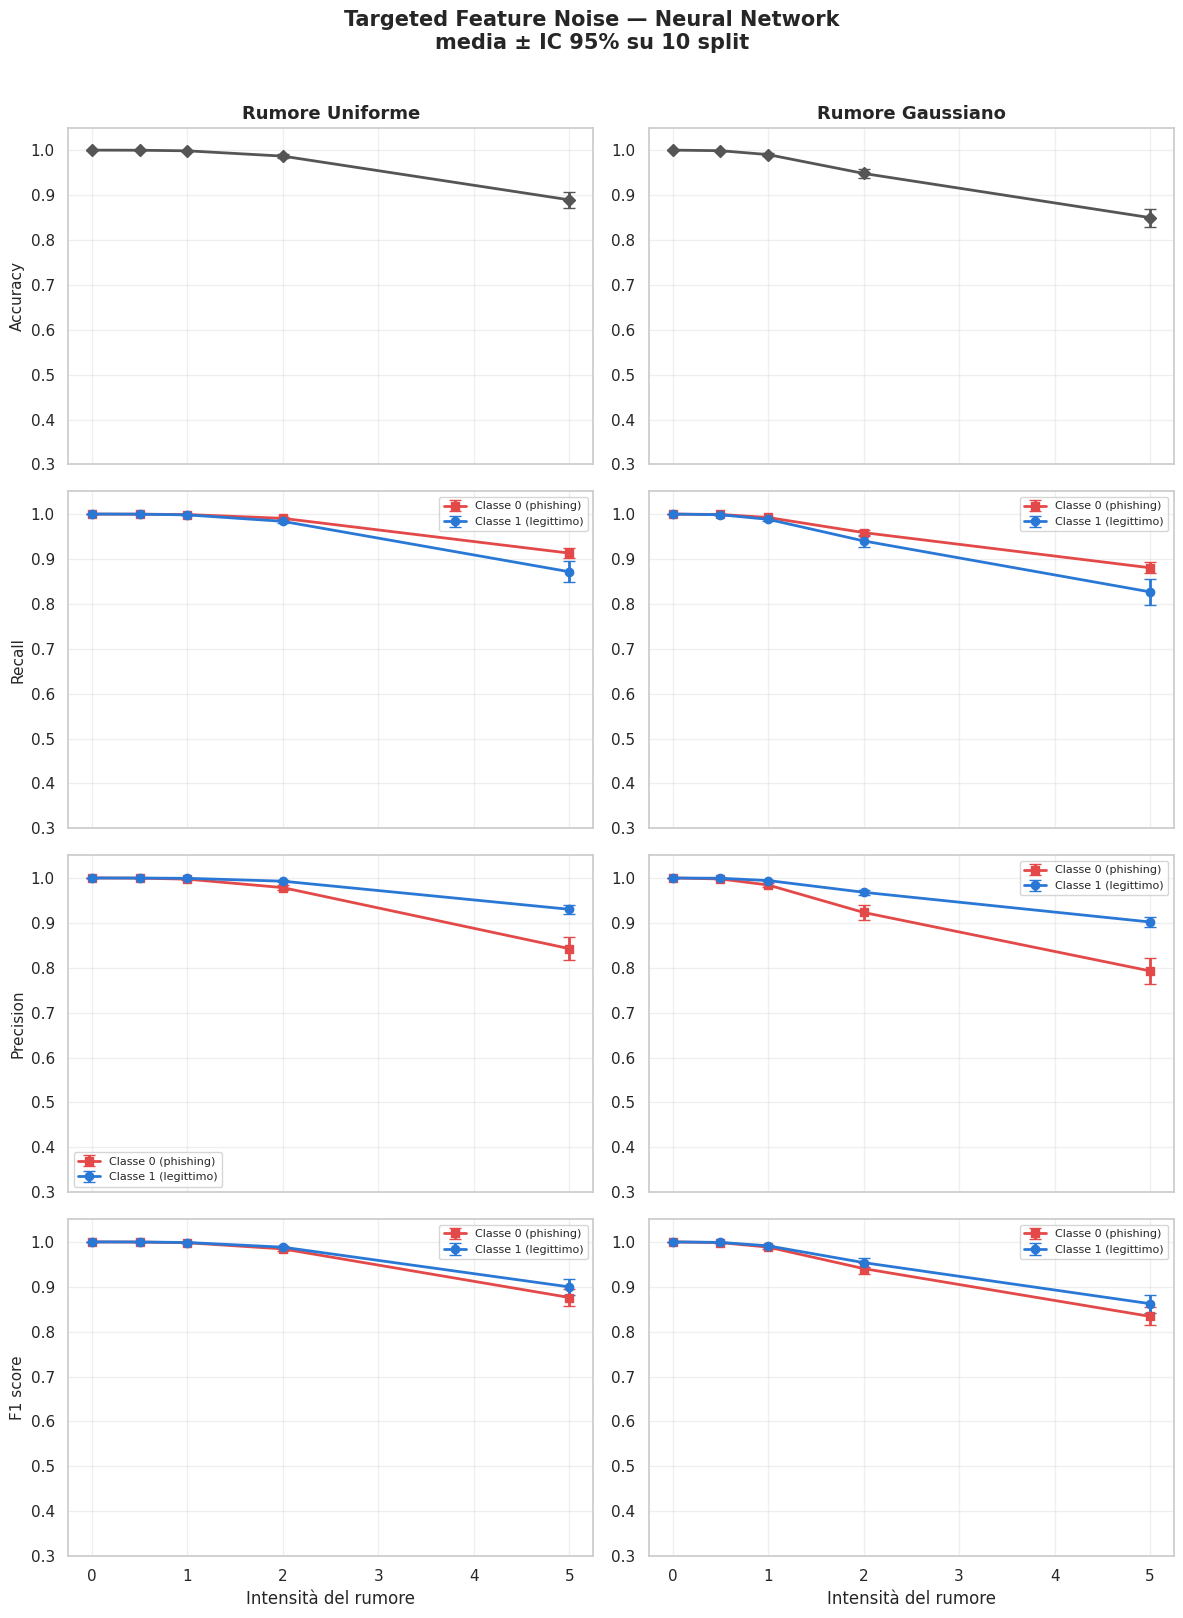

In [ ]:
# Input:  df_raw ha una riga per ogni combinazione (split, noise_type, noise_level)
#         -> con N=5 split, 2 noise_type, 5 noise_level = 100 righe
# Output: df compatto con una riga per ogni combinazione (noise_type, noise_level)
#         -> 2 x 5 = 10 righe, con media e IC 95% calcolati sui 10 split

def aggrega_targeted(df_raw):
    metriche = ['accuracy', 'precision_0', 'precision_1',
                'recall_0', 'recall_1', 'f1_0', 'f1_1']

    # Raggruppo le righe che condividono lo stesso (noise_type, noise_level)
    # -> ogni gruppo conterrà N righe, una per split
    grouped = df_raw.groupby(['noise_type', 'noise_level'])

    righe = []
    for (noise_type, level), g in grouped:
        riga = {'noise_type': noise_type, 'noise_level': level}
        for m in metriche:
            vals = g[m].values  # gli N valori della metrica per questo gruppo (uno per split)

            riga[m] = vals.mean()  # media della metrica sugli N split

            # IC 95%: stessa formula usata per la MCAR (1.96 * errore standard)
            riga[f'{m}_ci'] = calculate_ic95(vals)

        righe.append(riga)

    # Ordino per tipo di rumore e livello, così il grafico avrà i punti in ordine crescente
    return pd.DataFrame(righe).sort_values(['noise_type', 'noise_level']).reset_index(drop=True)

# Eseguo l'aggregazione sui due df grezzi ottenuti dai blocchi N-fold precedenti
# (uno per il Decision Tree, uno per la Neural Network)
df_targeted_dt_agg = aggrega_targeted(df_risultati_targeted_dt_raw)
df_targeted_nn_agg = aggrega_targeted(df_risultati_targeted_nn_raw)

def plot_targeted_noise_verticale_ci(df, titolo_modello, scala_y):
    # Separo i dati aggregati per tipo di rumore (una colonna del grafico per tipo)
    df_uniform  = df[df['noise_type'] == 'uniform']
    df_gaussian = df[df['noise_type'] == 'gaussian']

    # Definisco le 4 righe della griglia: (metrica classe 0, metrica classe 1, titolo)
    # accuracy non ha classi separate -> m1 = None
    righe = [
        ('accuracy', None, 'Accuracy'),
        ('recall_0', 'recall_1', 'Recall'),
        ('precision_0', 'precision_1', 'Precision'),
        ('f1_0', 'f1_1', 'F1 score'),
    ]

    fig, axes = plt.subplots(len(righe), 2, figsize=(12, 4 * len(righe)), sharex=True)
    colonne = [(df_uniform, 'Rumore Uniforme'), (df_gaussian, 'Rumore Gaussiano')]

    # Ciclo su ogni combinazione (colonna = tipo di rumore) x (riga = metrica)
    for col_idx, (df_noise, noise_label) in enumerate(colonne):
        for row_idx, (m0, m1, title) in enumerate(righe):
            ax = axes[row_idx, col_idx]

            if m1 is None:
                # Caso accuracy: un'unica linea con error bar
                ax.errorbar(df_noise['noise_level'], df_noise[m0], yerr=df_noise[f'{m0}_ci'],
                             marker='D', color='#555555', linewidth=2, capsize=4)
            else:
                # Caso metriche per classe: due linee con error bar (classe 0 e classe 1)
                ax.errorbar(df_noise['noise_level'], df_noise[m0], yerr=df_noise[f'{m0}_ci'],
                             marker='s', color='#e34948', linewidth=2, capsize=4, label='Classe 0 (phishing)')
                ax.errorbar(df_noise['noise_level'], df_noise[m1], yerr=df_noise[f'{m1}_ci'],
                             marker='o', color='#2a78d6', linewidth=2, capsize=4, label='Classe 1 (legittimo)')
                ax.legend(fontsize=8)

            ax.set_ylim(scala_y, 1.05)
            ax.grid(True, alpha=0.3)

            # Titolo colonna solo sulla prima riga
            if row_idx == 0:
                ax.set_title(noise_label, fontsize=13, fontweight='600')

            # Etichetta riga solo sulla prima colonna
            if col_idx == 0:
                ax.set_ylabel(title, fontsize=11, fontweight='500')

            # Xlabel solo sull'ultima riga
            if row_idx == len(righe) - 1:
                ax.set_xlabel('Intensità del rumore')

    # Titolo generale del grafico, con nota su N split (coerente con i grafici MCAR)
    plt.suptitle(f'Targeted Feature Noise — {titolo_modello}\nmedia ± IC 95% su {N} split',
                 fontsize=15, fontweight='600', y=1.01)
    plt.tight_layout()

    # Salvo il grafico in PDF (come fatto per la MCAR) e lo mostro a schermo
    plt.savefig(f'targeted_noise_{titolo_modello.replace(" ", "_")}.pdf', bbox_inches='tight')
    plt.show()

# generano effettivamente i due grafici in output
plot_targeted_noise_verticale_ci(df_targeted_dt_agg, 'Decision Tree', 0.3)
plot_targeted_noise_verticale_ci(df_targeted_nn_agg, 'Neural Network', 0.3)

### Mimicry Attack


Mimicry Attak(10 Split Stratificati, centroide='median')
Elaborazione Fold 1/10...
Elaborazione Fold 2/10...
Elaborazione Fold 3/10...
Elaborazione Fold 4/10...
Elaborazione Fold 5/10...
Elaborazione Fold 6/10...
Elaborazione Fold 7/10...
Elaborazione Fold 8/10...
Elaborazione Fold 9/10...
Elaborazione Fold 10/10...
Sperimentazione completata con successo!
Risultati grezzi salvati in raw_results_dt.csv e raw_results_nn.csv

Degrado performance Phishing (Classe 0) 

Decision Tree
 alpha  recall_0  recall_0_ci  precision_0  precision_0_ci
  0.00  0.995072     0.000389     0.995241        0.000980
  0.25  0.773951     0.007688     0.993891        0.001254
  0.50  0.771202     0.009109     0.993872        0.001246
  0.75  0.676106     0.007855     0.993013        0.001433
  1.00  0.676106     0.007855     0.993013        0.001433

Neural Network
 alpha  recall_0  recall_0_ci  precision_0  precision_0_ci
  0.00  0.999529     0.000164     0.999653        0.000107
  0.25  0.998484     0.00019

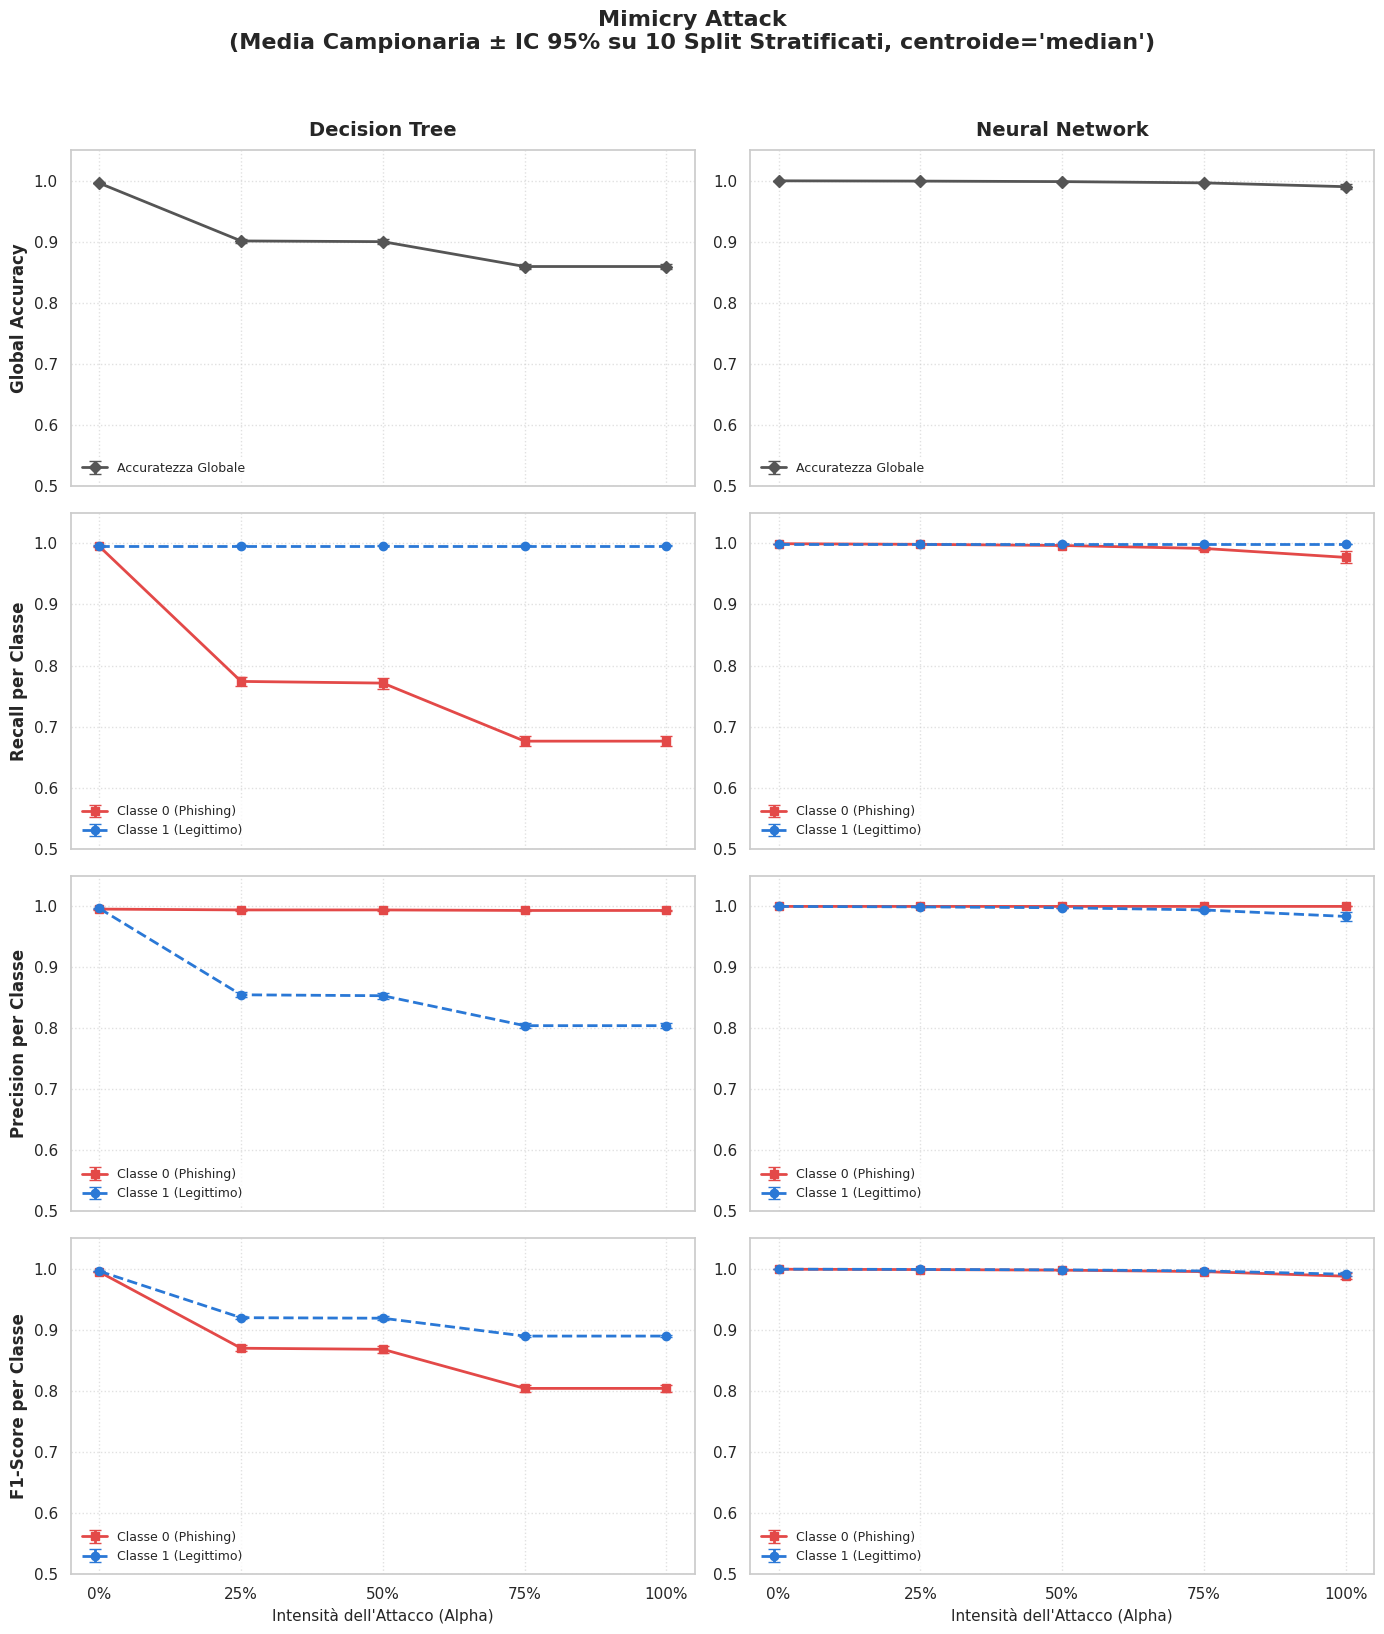

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # silenzia i log INFO/WARNING di TF

TARGET_FEATURES = ['NoOfImage', 'LineOfCode', 'NoOfSelfRef', 'NoOfExternalRef']
COUNT_FEATURES = ['NoOfImage', 'LineOfCode', 'NoOfSelfRef', 'NoOfExternalRef']
RATIO_FEATURES = []  # eventuali feature in range [0,1] (es. LetterRatioInURL)

ALPHA_LEVELS = [0.0, 0.25, 0.50, 0.75, 1.0]
N_SPLITS = 10

CENTROID_STRATEGY = 'median'
N_CLUSTERS = 3  # usato solo se CENTROID_STRATEGY == 'cluster'

sss = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)


def clip_to_domain(col_name, values, count_cols, ratio_cols):
    if col_name in count_cols:
        return np.clip(np.round(values), 0, None)
    elif col_name in ratio_cols:
        return np.clip(values, 0.0, 1.0)
    return values


def calculate_ic95(vals):
    vals = np.asarray(vals)
    n = len(vals)
    if n <= 1:
        return 0.0
    t_crit = t_dist.ppf(0.975, df=n - 1)
    return t_crit * vals.std(ddof=1) / np.sqrt(n)


def compute_target_profile(train_legitimate, phishing_subset, target_features,
                            strategy='median', n_clusters=3, seed=42):

    if strategy == 'mean':
        mu = train_legitimate[target_features].mean()
        return pd.DataFrame([mu.values] * len(phishing_subset),
                             columns=target_features, index=phishing_subset.index)

    elif strategy == 'median':
        mu = train_legitimate[target_features].median()
        return pd.DataFrame([mu.values] * len(phishing_subset),
                             columns=target_features, index=phishing_subset.index)

    elif strategy == 'cluster':
        km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        cluster_labels_train = km.fit_predict(train_legitimate[target_features])
        centroids = pd.DataFrame(km.cluster_centers_, columns=target_features)

        # per ogni campione phishing, assegna il centroide del cluster
        # legittimo piu' vicino (nello spazio delle TARGET_FEATURES)
        nearest_cluster = km.predict(phishing_subset[target_features])
        target_df = centroids.iloc[nearest_cluster].reset_index(drop=True)
        target_df.index = phishing_subset.index
        return target_df

    else:
        raise ValueError(f"Strategia centroide non riconosciuta: {strategy}")


raw_results_dt = []
raw_results_nn = []

print(f"Mimicry Attak({N_SPLITS} Split Stratificati, "
      f"centroide='{CENTROID_STRATEGY}')")

for fold, (train_idx, test_idx) in enumerate(sss.split(X_model, y_model), 1):
    print(f"Elaborazione Fold {fold}/{N_SPLITS}...")

    X_train_sp, X_test_sp = X_model.iloc[train_idx].copy(), X_model.iloc[test_idx].copy()
    y_train_sp, y_test_sp = y_model.iloc[train_idx], y_model.iloc[test_idx]

    train_legitimate = X_train_sp[y_train_sp == 1]
    idx_phishing_test = y_test_sp[y_test_sp == 0].index
    phishing_subset = X_test_sp.loc[idx_phishing_test]

    # Profilo/i bersaglio calcolato ESCLUSIVAMENTE sul train locale
    target_profile = compute_target_profile(
        train_legitimate, phishing_subset, TARGET_FEATURES,
        strategy=CENTROID_STRATEGY, n_clusters=N_CLUSTERS, seed=fold
    )

    #addestramento modelli sui dati integri del Fold
    dt_model = DecisionTreeClassifier(max_depth=7, min_samples_split=2,
                                       random_state=42, class_weight='balanced')
    dt_model.fit(X_train_sp, y_train_sp)

    scaler = StandardScaler()
    X_train_std_sp = scaler.fit_transform(X_train_sp)

    nn_model = build_nn_model(X_train_std_sp.shape[1], X_train_std_sp, y_train_sp, seed=fold, verbose = 0)

    for alpha in ALPHA_LEVELS:
        X_test_mimic = X_test_sp.copy()
        X_test_mimic[TARGET_FEATURES] = X_test_mimic[TARGET_FEATURES].astype(float)

        for col in TARGET_FEATURES:
            valori_attuali = X_test_sp.loc[idx_phishing_test, col]
            valori_target = target_profile[col]

            # Formula geometrica: X_mimic = X_phish + alpha * (target - X_phish)
            nuovi_valori = valori_attuali + alpha * (valori_target - valori_attuali)

            # Sanificazione applicata SOLO ai campioni perturbati (non a tutta
            # la colonna: i legittimi non vengono mai toccati)
            nuovi_valori = clip_to_domain(col, nuovi_valori.values, COUNT_FEATURES, RATIO_FEATURES)
            X_test_mimic.loc[idx_phishing_test, col] = nuovi_valori

        if alpha == 0.0:
            assert np.allclose(
                X_test_mimic.loc[idx_phishing_test, TARGET_FEATURES].astype(float).values,
                X_test_sp.loc[idx_phishing_test, TARGET_FEATURES].astype(float).values
            ), f"[Fold {fold}] Alpha=0 non coincide con i dati originali: controllare clipping/dtype."

        #valutazione per il decision tree
        y_pred_dt = dt_model.predict(X_test_mimic)
        prec_dt, rec_dt, f1_dt, _ = precision_recall_fscore_support(
            y_test_sp, y_pred_dt, labels=[0, 1], zero_division=0)

        raw_results_dt.append({
            'fold': fold, 'alpha': alpha,
            'accuracy': accuracy_score(y_test_sp, y_pred_dt),
            'precision_0': prec_dt[0], 'precision_1': prec_dt[1],
            'recall_0': rec_dt[0], 'recall_1': rec_dt[1],
            'f1_0': f1_dt[0], 'f1_1': f1_dt[1]
        })

        # valutazione per la rete neurale
        X_test_mimic_std = scaler.transform(X_test_mimic)
        y_prob_nn = nn_model.predict(X_test_mimic_std, batch_size=2048, verbose=0).ravel()
        y_pred_nn = (y_prob_nn >= 0.5).astype(int)
        prec_nn, rec_nn, f1_nn, _ = precision_recall_fscore_support(
            y_test_sp, y_pred_nn, labels=[0, 1], zero_division=0)

        raw_results_nn.append({
            'fold': fold, 'alpha': alpha,
            'accuracy': accuracy_score(y_test_sp, y_pred_nn),
            'precision_0': prec_nn[0], 'precision_1': prec_nn[1],
            'recall_0': rec_nn[0], 'recall_1': rec_nn[1],
            'f1_0': f1_nn[0], 'f1_1': f1_nn[1]
        })

print("Sperimentazione completata con successo!")

df_raw_dt = pd.DataFrame(raw_results_dt)
df_raw_nn = pd.DataFrame(raw_results_nn)

df_raw_dt.to_csv('raw_results_dt.csv', index=False)
df_raw_nn.to_csv('raw_results_nn.csv', index=False)
print("Risultati grezzi salvati in raw_results_dt.csv e raw_results_nn.csv")

metrics_list = ['accuracy', 'precision_0', 'precision_1', 'recall_0', 'recall_1', 'f1_0', 'f1_1']


def aggregate_experiment(df_raw):
    grouped = df_raw.groupby('alpha')
    aggregated_rows = []
    for alpha, group in grouped:
        row = {'alpha': alpha}
        for metric in metrics_list:
            values = group[metric].values
            row[metric] = values.mean()
            row[f'{metric}_ci'] = calculate_ic95(values)
        aggregated_rows.append(row)
    return pd.DataFrame(aggregated_rows).sort_values('alpha').reset_index(drop=True)


df_dt_agg = aggregate_experiment(df_raw_dt)
df_nn_agg = aggregate_experiment(df_raw_nn)

print("\nDegrado performance Phishing (Classe 0) ")
print("\nDecision Tree")
print(df_dt_agg[['alpha', 'recall_0', 'recall_0_ci', 'precision_0', 'precision_0_ci']].to_string(index=False))
print("\nNeural Network")
print(df_nn_agg[['alpha', 'recall_0', 'recall_0_ci', 'precision_0', 'precision_0_ci']].to_string(index=False))

def paired_significance_report(df_raw, model_name, metric='recall_0'):
    print(f"\n[{model_name}] Test appaiati su '{metric}' (baseline: alpha=0.0)")
    baseline = df_raw[df_raw.alpha == 0.0].sort_values('fold')[metric].values

    for alpha in ALPHA_LEVELS:
        if alpha == 0.0:
            continue
        comparison = df_raw[df_raw.alpha == alpha].sort_values('fold')[metric].values

        t_stat, p_t = ttest_rel(baseline, comparison)
        try:
            w_stat, p_w = wilcoxon(baseline, comparison)
        except ValueError:
            # capita se le differenze sono tutte zero
            p_w = float('nan')

        delta = comparison.mean() - baseline.mean()
        print(f"  alpha={alpha:.2f} | delta medio={delta:+.4f} | "
              f"paired t-test p={p_t:.2e} | wilcoxon p={p_w:.2e}")


paired_significance_report(df_raw_dt, "Decision tree", metric='recall_0')
paired_significance_report(df_raw_nn, "Neural Network", metric='recall_0')

plot_configs = [
    ('accuracy', None, 'Global Accuracy'),
    ('recall_0', 'recall_1', 'Recall per Classe'),
    ('precision_0', 'precision_1', 'Precision per Classe'),
    ('f1_0', 'f1_1', 'F1-Score per Classe')
]

x_ticks = ALPHA_LEVELS
x_labels = [f"{int(a * 100)}%" for a in ALPHA_LEVELS]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
models_data = [(df_dt_agg, 'Decision Tree'), (df_nn_agg, 'Neural Network')]

for col_idx, (df_model, model_title) in enumerate(models_data):
    for row_idx, (m0, m1, title_name) in enumerate(plot_configs):
        ax = axes[row_idx, col_idx]

        if m1 is None:
            ax.errorbar(df_model['alpha'], df_model[m0], yerr=df_model[f'{m0}_ci'],
                        marker='D', linestyle='-', color='#555555', linewidth=2,
                        capsize=4, label='Accuratezza Globale')
        else:
            ax.errorbar(df_model['alpha'], df_model[m0], yerr=df_model[f'{m0}_ci'],
                        marker='s', linestyle='-', color='#e34948', linewidth=2,
                        capsize=4, label='Classe 0 (Phishing)')
            ax.errorbar(df_model['alpha'], df_model[m1], yerr=df_model[f'{m1}_ci'],
                        marker='o', linestyle='--', color='#2a78d6', linewidth=2,
                        capsize=4, label='Classe 1 (Legittimo)')

        ax.set_ylim(0.5, 1.05)
        ax.grid(True, linestyle=':', alpha=0.6)

        if row_idx == 0:
            ax.set_title(model_title, fontsize=14, fontweight='bold', pad=10)
        if col_idx == 0:
            ax.set_ylabel(title_name, fontsize=12, fontweight='600')
        if row_idx == 3:
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels)
            ax.set_xlabel("Intensità dell'Attacco (Alpha)", fontsize=11)

        ax.legend(loc='lower left', fontsize=9, frameon=True, facecolor='white', edgecolor='none')

plt.suptitle(
    f"Mimicry Attack\n"
    f"(Media Campionaria ± IC 95% su {N_SPLITS} Split Stratificati, centroide='{CENTROID_STRATEGY}')",
    fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('mimicry_attack_degradation_report.pdf', bbox_inches='tight')
plt.show()